In [1]:
import os
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [3]:
def LoadCSV(dir_path):
    """
    讀取挑戰賽提供的3個資料集：交易資料、警示帳戶註記、待預測帳戶清單
    Args:
        dir_path (str): 資料夾，請把上述3個檔案放在同一個資料夾
    
    Returns:
        df_txn: 交易資料 DataFrame
        df_alert: 警示帳戶註記 DataFrame
        df_test: 待預測帳戶清單 DataFrame
    """
    df_txn = pd.read_csv(os.path.join(dir_path, 'acct_transaction.csv'))
    df_alert = pd.read_csv(os.path.join(dir_path, 'acct_alert.csv'))
    df_test = pd.read_csv(os.path.join(dir_path, 'acct_predict.csv'))
    
    print("(Finish) Load Dataset.")
    return df_txn, df_alert, df_test

In [4]:
dir_path = "./data/"
df_txn, df_alert, df_test = LoadCSV(dir_path)

(Finish) Load Dataset.


In [5]:
currency_types = df_txn['currency_type'].unique()
print('all currency types:')
print(currency_types)
print('---------------------------------------------------------')

channel_types = df_txn['channel_type'].unique()
print('all channel type:')
print(channel_types)
print('---------------------------------------------------------')

is_self_txn = df_txn['is_self_txn'].unique()
print('is_self_txn:')
print(is_self_txn)

# 定義每種貨幣對台幣的匯率
rate_dict = {
    'TWD': 1,
    'USD': 30.5,
    'JPY': 0.22,
    'AUD': 20.5,
    'CNY': 4.3,
    'EUR': 33.0,
    'SEK': 2.7,
    'GBP': 39.0,
    'HKD': 3.9,
    'THB': 0.88,
    'CAD': 23.0,
    'NZD': 19.5,
    'CHF': 33.5,
    'SGD': 23.0,
    'ZAR': 1.8,
    'MXN': 1.7
}

# 新增一欄 twd_amt 為台幣金額
df_txn['twd_amt'] = df_txn.apply(lambda row: row['txn_amt'] * rate_dict.get(row['currency_type'], 1), axis=1)


all currency types:
['TWD' 'USD' 'JPY' 'AUD' 'CNY' 'EUR' 'SEK' 'GBP' 'HKD' 'THB' 'CAD' 'NZD'
 'CHF' 'SGD' 'ZAR' 'MXN']
---------------------------------------------------------
all channel type:
['04' '03' 'UNK' '06' '05' '02' '01' '99' '07']
---------------------------------------------------------
is_self_txn:
['N' 'UNK' 'Y']


In [8]:
df_txn

,from_acct,from_acct_type,to_acct,to_acct_type,is_self_txn,txn_amt,txn_date,txn_time,currency_type,channel_type,twd_amt
0,be6fdd2d0f9aa02b0b09436fb137654942e3346e16ab43...,1,7abb16ac9bddc1f464981131ba68506775a964df2e0734...,1,N,47500.0,71,05:05:00,TWD,04,47500.0
1,18f3d0e79217f8bc8b4cb485f9f80a884771b846de652f...,1,e77e425fb5f3ece7a7b431b3c43cc1d040f3054e35479d...,2,UNK,6150.0,31,20:55:00,TWD,03,6150.0
2,302f3911cbf56bf9b5ad209a4b045a82380f98d92604c1...,1,4a707a0af2aa824777082803013610090033104c308023...,1,N,1150000.0,37,09:20:00,TWD,04,1150000.0
3,5a4809796865b1526f46e5dda6a35c1a4def3cbe969cc8...,1,d16b1bf33802f020b508002755c13aad549bc59dde7aae...,2,UNK,8550.0,106,13:40:00,TWD,04,8550.0
4,7f84214987bdee16ffbaf3d70824e6385ce80e032a24c5...,1,c2e0f75b54f394b29755779ab9a488931e9d893a0e5f8f...,1,N,1450.0,84,11:20:00,TWD,03,1450.0
...,...,...,...,...,...,...,...,...,...,...,...
4435885,a8e4855e85cbd465b2f643bae62956e4b982ab20708000...,1,ba45be62c9cb05d0f43169f6958c1870b0500fa0abc48b...,2,UNK,285.0,87,17:10:00,TWD,03,285.0
4435886,fad742556efbb90f999fea49b0a212c2ac12a7baf71869...,1,49775a8223d99b07dc975ccda5c2f7a8c84088a4717610...,2,UNK,505.0,55,21:45:00,TWD,03,505.0
4435887,d5f8cf2a8beebb2ae627c506d661826b555e19b74a5efb...,2,f8fff2b79f98d937b3991ea5736c6bab99b9999a6bb732...,1,UNK,1150.0,95,13:00:00,TWD,UNK,1150.0
4435888,64e579f4be2d77d38e931391eb6b791e1adf576f273a44...,2,8a6aab8bf9e36d0dd5ea481c923c3979c54e9401cc6a9d...,2,N,1050.0,23,19:10:00,TWD,06,1050.0


# Data Preprocessing

## 匯款帳戶資訊

In [7]:
# 金額數量相關
send_max = df_txn.groupby('from_acct')['twd_amt'].max().rename('send_max')
send_min = df_txn.groupby('from_acct')['twd_amt'].min().rename('send_min')
send_avg = df_txn.groupby('from_acct')['twd_amt'].mean().rename('send_avg')
send_sum = df_txn.groupby('from_acct')['twd_amt'].sum().rename('send_sum')

# 計算匯款頻率
send_count = df_txn.groupby('from_acct')['twd_amt'].count().rename('send_count')    
send_begin = df_txn.groupby('from_acct')['txn_date'].min().rename('send_begin')
send_end = df_txn.groupby('from_acct')['txn_date'].max().rename('send_end')
send_timespan = (send_end - send_begin + 1).rename('send_timespan')
send_freq = (send_count / send_timespan).rename('send_freq')

send_features = [send_max, send_min, send_avg, send_sum, send_count, send_freq]
send = pd.concat(send_features, axis=1)
send

,send_max,send_min,send_avg,send_sum,send_count,send_freq
from_acct,,,,,,
00000eec52ea49377de91bc7b54eb3192943e6c20e0a51413dc1e733ee0dfad8,205.0,205.0,205.000000,205.0,1,1.000000
000015150c92e2a41c4715a088df78d77a7d4f3017aadc3493d15a72fbeaf89c,585.0,585.0,585.000000,585.0,1,1.000000
0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01bb0aca7412c8666933,20500.0,20500.0,20500.000000,20500.0,1,1.000000
000047d4d4551618c647b5bc602ecaeb7f42bbdece075096495644afd0c118ac,5050.0,5050.0,5050.000000,5050.0,1,1.000000
00007e8eec41727b71aca0e00cf26c75bd96babafa52035b92b50d3375e1a013,12500.0,1050.0,4500.000000,31500.0,7,0.118644
...,...,...,...,...,...,...
ffff781c72fb6d7d636d2e8f33463c73b3e76bfb6d8a0d3955e40b94fda05e66,1350.0,1350.0,1350.000000,1350.0,1,1.000000
ffffadfe02d29c1b1cb1c05dc06d9475ec6b35485c6394c7b5c8dd70bc62f5ed,3050.0,3050.0,3050.000000,3050.0,1,1.000000
ffffb1165f2ca552ef09cf0e2a652fe42bbfa1a0467511c0f582c0e080a81a95,29500.0,2150.0,6933.333333,62400.0,9,0.109756


## 收款帳戶資訊

In [6]:
# 金額數量相關
recv_max = df_txn.groupby('to_acct')['twd_amt'].max().rename('recv_max')
recv_min = df_txn.groupby('to_acct')['twd_amt'].min().rename('recv_min')
recv_avg = df_txn.groupby('to_acct')['twd_amt'].mean().rename('recv_avg')
recv_sum = df_txn.groupby('to_acct')['twd_amt'].sum().rename('recv_sum')

# 計算匯款頻率
recv_count = df_txn.groupby('to_acct')['twd_amt'].count().rename('recv_count')    
recv_begin = df_txn.groupby('to_acct')['txn_date'].min().rename('recv_begin')
recv_end = df_txn.groupby('to_acct')['txn_date'].max().rename('recv_end')
recv_timespan = (recv_end - recv_begin + 1).rename('recv_timespan')
recv_freq = (recv_count / recv_timespan).rename('recv_freq')

recv_features = [recv_max, recv_min, recv_avg, recv_sum, recv_count, recv_freq]
recv = pd.concat(recv_features, axis=1)
recv

,recv_max,recv_min,recv_avg,recv_sum,recv_count,recv_freq
to_acct,,,,,,
00000577cfcd0bde8ee693021419ef13a1f7f933ec862626d866616af32f2978,4050.0,4050.0,4050.0,4050.0,1,1.000000
00002846e6b430580825e2b10fe3ff1e3ddb93f42c608daa8679723a694eb40d,3050.0,3050.0,3050.0,3050.0,1,1.000000
00002b3d8f9c7b91c407a5725849deb521fcf1dd5eea1fffa217980d912b6fde,75.0,75.0,75.0,75.0,1,1.000000
0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01bb0aca7412c8666933,50500.0,17500.0,34000.0,68000.0,2,0.400000
00003f3fb30775e809a2e02924f57f360f3d02e89cbd82988b82fa9917fdc676,3050.0,3050.0,3050.0,3050.0,1,1.000000
...,...,...,...,...,...,...
ffffadfe02d29c1b1cb1c05dc06d9475ec6b35485c6394c7b5c8dd70bc62f5ed,10500.0,1550.0,6025.0,12050.0,2,0.333333
ffffb539101ccf825bac965d6b0d88ca323e02c17c22bea2a314f47abe7f4e4a,14500.0,14500.0,14500.0,14500.0,1,1.000000
ffffd0e26ce48dddeb6961506c8faaaa0c89159ad4b1cc2a44c14d6df7655c86,7650.0,7650.0,7650.0,7650.0,1,1.000000


## 匯款收款帳戶合併

In [8]:
txn = pd.concat([send, recv], axis=1).fillna(0)
txn = txn.reset_index().rename(columns={'index':'acct'}).set_index('acct')
txn

,send_max,send_min,send_avg,send_sum,send_count,send_freq,recv_max,recv_min,recv_avg,recv_sum,recv_count,recv_freq
acct,,,,,,,,,,,,
00000eec52ea49377de91bc7b54eb3192943e6c20e0a51413dc1e733ee0dfad8,205.0,205.0,205.0,205.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
000015150c92e2a41c4715a088df78d77a7d4f3017aadc3493d15a72fbeaf89c,585.0,585.0,585.0,585.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01bb0aca7412c8666933,20500.0,20500.0,20500.0,20500.0,1.0,1.000000,50500.0,17500.0,34000.0,68000.0,2.0,0.4
000047d4d4551618c647b5bc602ecaeb7f42bbdece075096495644afd0c118ac,5050.0,5050.0,5050.0,5050.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
00007e8eec41727b71aca0e00cf26c75bd96babafa52035b92b50d3375e1a013,12500.0,1050.0,4500.0,31500.0,7.0,0.118644,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
ffffabb5ab2a1cd42beccca39232b464c9c67b1dbf29492d363121faa61a26d5,0.0,0.0,0.0,0.0,0.0,0.000000,9050.0,9050.0,9050.0,9050.0,1.0,1.0
ffffb539101ccf825bac965d6b0d88ca323e02c17c22bea2a314f47abe7f4e4a,0.0,0.0,0.0,0.0,0.0,0.000000,14500.0,14500.0,14500.0,14500.0,1.0,1.0
ffffd0e26ce48dddeb6961506c8faaaa0c89159ad4b1cc2a44c14d6df7655c86,0.0,0.0,0.0,0.0,0.0,0.000000,7650.0,7650.0,7650.0,7650.0,1.0,1.0


## 交易方式比例

In [12]:
txn_method = ['04' '03' 'UNK' '06' '05' '02' '01' '99' '07'] 

In [13]:
send_channel = df_txn.pivot_table(index = 'from_acct', columns = 'channel_type', aggfunc='size', fill_value=0)
send_channel.columns = [f'channel_{col}_sd' for col in send_channel.columns]
send_channel_sum = send_channel.sum(axis=1)
send_channel = send_channel.div(send_channel_sum, axis=0)
send_channel.reset_index().head(100)

recv_channel = df_txn.pivot_table(index = 'to_acct', columns = 'channel_type', aggfunc='size', fill_value=0)
recv_channel.columns = [f'channel_{col}_rc' for col in recv_channel.columns]
recv_channel_sum = recv_channel.sum(axis=1)
recv_channel = recv_channel.div(recv_channel_sum, axis=0)
recv_channel.reset_index().head(100)

channel = pd.concat([send_channel, recv_channel], axis=1).fillna(0)
channel = channel.reset_index().rename(columns={'index':'acct'}).set_index('acct')
channel

,channel_01_sd,channel_02_sd,channel_03_sd,channel_04_sd,channel_05_sd,channel_06_sd,channel_07_sd,channel_99_sd,channel_UNK_sd,channel_01_rc,channel_02_rc,channel_03_rc,channel_04_rc,channel_05_rc,channel_06_rc,channel_07_rc,channel_99_rc,channel_UNK_rc
acct,,,,,,,,,,,,,,,,,,
00000eec52ea49377de91bc7b54eb3192943e6c20e0a51413dc1e733ee0dfad8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000015150c92e2a41c4715a088df78d77a7d4f3017aadc3493d15a72fbeaf89c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01bb0aca7412c8666933,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.5
000047d4d4551618c647b5bc602ecaeb7f42bbdece075096495644afd0c118ac,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00007e8eec41727b71aca0e00cf26c75bd96babafa52035b92b50d3375e1a013,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffffabb5ab2a1cd42beccca39232b464c9c67b1dbf29492d363121faa61a26d5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
ffffb539101ccf825bac965d6b0d88ca323e02c17c22bea2a314f47abe7f4e4a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
ffffd0e26ce48dddeb6961506c8faaaa0c89159ad4b1cc2a44c14d6df7655c86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 使用貨幣比例

In [15]:
currencies = ['TWD' 'USD' 'JPY' 'AUD' 'CNY' 'EUR' 'SEK' 'GBP' 'HKD' 'THB' 'CAD' 'NZD'
 'CHF' 'SGD' 'ZAR' 'MXN']

In [14]:
send_currency = df_txn.pivot_table(index = 'from_acct', columns = 'currency_type', aggfunc='size', fill_value=0)
send_currency.columns = [f'currency_{col}_sd' for col in send_currency.columns]
send_currency_sum = send_currency.sum(axis=1)
send_currency = send_currency.div(send_currency_sum, axis=0)

recv_currency = df_txn.pivot_table(index = 'to_acct', columns = 'currency_type', aggfunc='size', fill_value=0)
recv_currency.columns = [f'currency_{col}_rc' for col in recv_currency.columns]
recv_currency_sum = recv_currency.sum(axis=1)
recv_currency = recv_currency.div(recv_currency_sum, axis=0)

currency = pd.concat([send_currency, recv_currency], axis=1).fillna(0)
currency = currency.reset_index().rename(columns={'index':'acct'}).set_index('acct')
currency


,currency_AUD_sd,currency_CAD_sd,currency_CHF_sd,currency_CNY_sd,currency_EUR_sd,currency_GBP_sd,currency_HKD_sd,currency_JPY_sd,currency_MXN_sd,currency_NZD_sd,...,currency_HKD_rc,currency_JPY_rc,currency_MXN_rc,currency_NZD_rc,currency_SEK_rc,currency_SGD_rc,currency_THB_rc,currency_TWD_rc,currency_USD_rc,currency_ZAR_rc
acct,,,,,,,,,,,,,,,,,,,,,
00000eec52ea49377de91bc7b54eb3192943e6c20e0a51413dc1e733ee0dfad8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000015150c92e2a41c4715a088df78d77a7d4f3017aadc3493d15a72fbeaf89c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01bb0aca7412c8666933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
000047d4d4551618c647b5bc602ecaeb7f42bbdece075096495644afd0c118ac,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00007e8eec41727b71aca0e00cf26c75bd96babafa52035b92b50d3375e1a013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffffabb5ab2a1cd42beccca39232b464c9c67b1dbf29492d363121faa61a26d5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ffffb539101ccf825bac965d6b0d88ca323e02c17c22bea2a314f47abe7f4e4a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ffffd0e26ce48dddeb6961506c8faaaa0c89159ad4b1cc2a44c14d6df7655c86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 帳戶持有人相同比例

In [15]:
send_self = df_txn.pivot_table(index='from_acct', columns='is_self_txn', aggfunc='size', fill_value=0)
send_self_sum = send_self.sum(axis=1)
send_self['Y'] = send_self['Y'] / send_self_sum
send_self = send_self.drop(columns=['N', 'UNK'])
send_self = send_self.reset_index()[['from_acct', 'Y']]
send_self.columns = ['acct', 'send_self']

recv_self = df_txn.pivot_table(index='to_acct', columns='is_self_txn', aggfunc='size', fill_value=0)
recv_self_sum = recv_self.sum(axis=1)
recv_self['Y'] = recv_self['Y'] / recv_self_sum
recv_self = recv_self.drop(columns=['N', 'UNK'])
recv_self = recv_self.reset_index()[['to_acct', 'Y']]
recv_self.columns = ['acct', 'recv_self']

self = pd.concat([send_self.set_index('acct'), recv_self.set_index('acct')], axis=1).fillna(0)
self

,send_self,recv_self
acct,,
00000eec52ea49377de91bc7b54eb3192943e6c20e0a51413dc1e733ee0dfad8,0.0,0.0
000015150c92e2a41c4715a088df78d77a7d4f3017aadc3493d15a72fbeaf89c,0.0,0.0
0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01bb0aca7412c8666933,0.0,0.0
000047d4d4551618c647b5bc602ecaeb7f42bbdece075096495644afd0c118ac,0.0,0.0
00007e8eec41727b71aca0e00cf26c75bd96babafa52035b92b50d3375e1a013,0.0,0.0
...,...,...
ffffabb5ab2a1cd42beccca39232b464c9c67b1dbf29492d363121faa61a26d5,0.0,0.0
ffffb539101ccf825bac965d6b0d88ca323e02c17c22bea2a314f47abe7f4e4a,0.0,0.0
ffffd0e26ce48dddeb6961506c8faaaa0c89159ad4b1cc2a44c14d6df7655c86,0.0,0.0


## 是否為玉山銀行

In [16]:
send_esun = df_txn[['from_acct', 'from_acct_type']].rename(columns={'from_acct': 'acct', 'from_acct_type': 'is_esun'})  
recv_esun = df_txn[['to_acct', 'to_acct_type']].rename(columns={'to_acct': 'acct', 'to_acct_type': 'is_esun'})

esun = pd.concat([send_esun, recv_esun], axis=0).drop_duplicates(subset = 'acct').set_index('acct')
esun
# esun


,is_esun
acct,
be6fdd2d0f9aa02b0b09436fb137654942e3346e16ab439aec2c1def2774af7f,1
18f3d0e79217f8bc8b4cb485f9f80a884771b846de652f1d26cff59ace9cb54c,1
302f3911cbf56bf9b5ad209a4b045a82380f98d92604c172ef64eeb0a12270c5,1
5a4809796865b1526f46e5dda6a35c1a4def3cbe969cc8c5b950aedc060211d2,1
7f84214987bdee16ffbaf3d70824e6385ce80e032a24c58ea3ce2b6336f16954,1
...,...
db6278962337ebbd46bea58fee6eab32ec026600a9084a3e5092bcbc38bd7951,2
edd4193a7361b76f1a3a7cc3b0da2f26d245ae10b715a5a5ed63705049eed195,2
49447dcab3dafd3cef72e8ec47e6ff115b6a8ec9c939f76f841eba19e24e3652,2


## 統整所有帳號的相關資訊

In [17]:
acct_info = pd.concat([txn, channel, currency,self, esun], axis=1).fillna(0)
acct_info

,send_max,send_min,send_avg,send_sum,send_count,send_freq,recv_max,recv_min,recv_avg,recv_sum,...,currency_NZD_rc,currency_SEK_rc,currency_SGD_rc,currency_THB_rc,currency_TWD_rc,currency_USD_rc,currency_ZAR_rc,send_self,recv_self,is_esun
acct,,,,,,,,,,,,,,,,,,,,,
00000eec52ea49377de91bc7b54eb3192943e6c20e0a51413dc1e733ee0dfad8,205.0,205.0,205.0,205.0,1.0,1.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
000015150c92e2a41c4715a088df78d77a7d4f3017aadc3493d15a72fbeaf89c,585.0,585.0,585.0,585.0,1.0,1.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01bb0aca7412c8666933,20500.0,20500.0,20500.0,20500.0,1.0,1.000000,50500.0,17500.0,34000.0,68000.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
000047d4d4551618c647b5bc602ecaeb7f42bbdece075096495644afd0c118ac,5050.0,5050.0,5050.0,5050.0,1.0,1.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
00007e8eec41727b71aca0e00cf26c75bd96babafa52035b92b50d3375e1a013,12500.0,1050.0,4500.0,31500.0,7.0,0.118644,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffffabb5ab2a1cd42beccca39232b464c9c67b1dbf29492d363121faa61a26d5,0.0,0.0,0.0,0.0,0.0,0.000000,9050.0,9050.0,9050.0,9050.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
ffffb539101ccf825bac965d6b0d88ca323e02c17c22bea2a314f47abe7f4e4a,0.0,0.0,0.0,0.0,0.0,0.000000,14500.0,14500.0,14500.0,14500.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
ffffd0e26ce48dddeb6961506c8faaaa0c89159ad4b1cc2a44c14d6df7655c86,0.0,0.0,0.0,0.0,0.0,0.000000,7650.0,7650.0,7650.0,7650.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1


In [18]:
acct_info.columns

Index(['send_max', 'send_min', 'send_avg', 'send_sum', 'send_count',
       'send_freq', 'recv_max', 'recv_min', 'recv_avg', 'recv_sum',
       'recv_count', 'recv_freq', 'channel_01_sd', 'channel_02_sd',
       'channel_03_sd', 'channel_04_sd', 'channel_05_sd', 'channel_06_sd',
       'channel_07_sd', 'channel_99_sd', 'channel_UNK_sd', 'channel_01_rc',
       'channel_02_rc', 'channel_03_rc', 'channel_04_rc', 'channel_05_rc',
       'channel_06_rc', 'channel_07_rc', 'channel_99_rc', 'channel_UNK_rc',
       'currency_AUD_sd', 'currency_CAD_sd', 'currency_CHF_sd',
       'currency_CNY_sd', 'currency_EUR_sd', 'currency_GBP_sd',
       'currency_HKD_sd', 'currency_JPY_sd', 'currency_MXN_sd',
       'currency_NZD_sd', 'currency_SEK_sd', 'currency_SGD_sd',
       'currency_THB_sd', 'currency_TWD_sd', 'currency_USD_sd',
       'currency_ZAR_sd', 'currency_AUD_rc', 'currency_CAD_rc',
       'currency_CHF_rc', 'currency_CNY_rc', 'currency_EUR_rc',
       'currency_GBP_rc', 'currency_HKD_rc', 

In [19]:
acct_info.reset_index()

,acct,send_max,send_min,send_avg,send_sum,send_count,send_freq,recv_max,recv_min,recv_avg,...,currency_NZD_rc,currency_SEK_rc,currency_SGD_rc,currency_THB_rc,currency_TWD_rc,currency_USD_rc,currency_ZAR_rc,send_self,recv_self,is_esun
0,00000eec52ea49377de91bc7b54eb3192943e6c20e0a51...,205.0,205.0,205.0,205.0,1.0,1.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,000015150c92e2a41c4715a088df78d77a7d4f3017aadc...,585.0,585.0,585.0,585.0,1.0,1.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01...,20500.0,20500.0,20500.0,20500.0,1.0,1.000000,50500.0,17500.0,34000.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
3,000047d4d4551618c647b5bc602ecaeb7f42bbdece0750...,5050.0,5050.0,5050.0,5050.0,1.0,1.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,00007e8eec41727b71aca0e00cf26c75bd96babafa5203...,12500.0,1050.0,4500.0,31500.0,7.0,0.118644,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800101,ffffabb5ab2a1cd42beccca39232b464c9c67b1dbf2949...,0.0,0.0,0.0,0.0,0.0,0.000000,9050.0,9050.0,9050.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
1800102,ffffb539101ccf825bac965d6b0d88ca323e02c17c22be...,0.0,0.0,0.0,0.0,0.0,0.000000,14500.0,14500.0,14500.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
1800103,ffffd0e26ce48dddeb6961506c8faaaa0c89159ad4b1cc...,0.0,0.0,0.0,0.0,0.0,0.000000,7650.0,7650.0,7650.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
1800104,ffffe17a29cfc2f790f187bf208323fd466509022c0e9e...,0.0,0.0,0.0,0.0,0.0,0.000000,1050.0,1050.0,1050.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2


# DATA PREPROCESSING

In [23]:

# 已確定被警示的帳戶所判斷的範圍是否侷限在基準日開始後的時間?
# ---------------------------------------------------------------------------------------------------
# 尚未使用到的欄位 'currency_type', 'acct_type', 'is_self_txn', 'txn_date', 'txn_time', 'event_date'
# 幣別是否加入one-hot選項?(可能使用不同貨幣交易)
# 根據匯率轉換實際金額數量
# send次數 send頻率 recv次數 recv頻率
# 取用數據應該局限於被警告之前(因為已足夠判斷出為警示用戶)
# 要找出每個帳戶的交易時間段 才能算出頻率等資訊
# 被警示的帳戶不會再有新的交易紀錄 所以警示帳戶的資料處理可以用event date來當作交易時間總長
# send to多少不同帳號 recv from至多少不同帳號 對同個帳號send的次數以及頻率和平均金額 
# 每種貨幣的匯款、收款次數
# 每種通道的匯款、收款次數
df = df_txn
send = df.groupby('from_acct')['txn_amt'].sum().rename('total_send_amt') # 未轉換幣別??
recv = df.groupby('to_acct')['txn_amt'].sum().rename('total_recv_amt')

max_send = df.groupby('from_acct')['txn_amt'].max().rename('max_send_amt')
min_send = df.groupby('from_acct')['txn_amt'].min().rename('min_send_amt')
avg_send = df.groupby('from_acct')['txn_amt'].mean().rename('avg_send_amt')

max_recv = df.groupby('to_acct')['txn_amt'].max().rename('max_recv_amt')
min_recv = df.groupby('to_acct')['txn_amt'].min().rename('min_recv_amt')
avg_recv = df.groupby('to_acct')['txn_amt'].mean().rename('avg_recv_amt')
# send = df.groupby('from_acct')['twd_amt'].sum().rename('total_send_amt') # 未轉換幣別??
# recv = df.groupby('to_acct')['twd_amt'].sum().rename('total_recv_amt')

# max_send = df.groupby('from_acct')['twd_amt'].max().rename('max_send_amt')
# min_send = df.groupby('from_acct')['twd_amt'].min().rename('min_send_amt')
# avg_send = df.groupby('from_acct')['twd_amt'].mean().rename('avg_send_amt')

# max_recv = df.groupby('to_acct')['twd_amt'].max().rename('max_recv_amt')
# min_recv = df.groupby('to_acct')['twd_amt'].min().rename('min_recv_amt')
# avg_recv = df.groupby('to_acct')['twd_amt'].mean().rename('avg_recv_amt')

df_result = pd.concat([max_send, min_send, avg_send, max_recv, min_recv, avg_recv, send, recv], axis=1).fillna(0).reset_index()
df_result.rename(columns={'index': 'acct'}, inplace=True)

# 2. 'is_esun': is esun account or not
df_from = df[['from_acct', 'from_acct_type']].rename(columns={'from_acct': 'acct', 'from_acct_type': 'is_esun'})
df_to = df[['to_acct', 'to_acct_type']].rename(columns={'to_acct': 'acct', 'to_acct_type': 'is_esun'})
df_acc = pd.concat([df_from, df_to], ignore_index=True).drop_duplicates().reset_index(drop=True)
df_result = pd.merge(df_result, df_acc, on='acct', how='left')    
print("(Finish) PreProcessing.")

(Finish) PreProcessing.


In [20]:
df = df_result

print('使用到的欄位')
print('-----------------------------------------------------------------')
df

NameError: name 'df_result' is not defined

In [21]:
df = acct_info.reset_index()

## 標準化處理

In [23]:
from sklearn.preprocessing import StandardScaler

# 只取數值特徵（排除帳號）
cols_to_scale = [col for col in df.columns if (col != 'acct' and col != 'is_esun')]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df = df_scaled

In [24]:
df

,acct,send_max,send_min,send_avg,send_sum,send_count,send_freq,recv_max,recv_min,recv_avg,...,currency_NZD_rc,currency_SEK_rc,currency_SGD_rc,currency_THB_rc,currency_TWD_rc,currency_USD_rc,currency_ZAR_rc,send_self,recv_self,is_esun
0,00000eec52ea49377de91bc7b54eb3192943e6c20e0a51...,-0.068539,-0.076113,-0.086819,-0.030293,-0.085019,1.092754,-0.089541,-0.102581,-0.120131,...,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286,2
1,000015150c92e2a41c4715a088df78d77a7d4f3017aadc...,-0.067396,-0.072125,-0.083883,-0.030191,-0.085019,1.092754,-0.089541,-0.102581,-0.120131,...,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286,2
2,0000319cf868e5a245bbe4726c9f8f0cbb7cbc03a9aa01...,-0.007491,0.136860,0.069951,-0.024827,-0.085019,1.092754,0.056037,0.036226,0.099001,...,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286,2
3,000047d4d4551618c647b5bc602ecaeb7f42bbdece0750...,-0.053965,-0.025270,-0.049393,-0.028988,-0.085019,1.092754,-0.089541,-0.102581,-0.120131,...,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286,2
4,00007e8eec41727b71aca0e00cf26c75bd96babafa5203...,-0.031556,-0.067246,-0.053642,-0.021864,0.263362,-0.341217,-0.089541,-0.102581,-0.120131,...,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800101,ffffabb5ab2a1cd42beccca39232b464c9c67b1dbf2949...,-0.069156,-0.078264,-0.088402,-0.030348,-0.143082,-0.534252,-0.063452,-0.030798,-0.061803,...,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286,2
1800102,ffffb539101ccf825bac965d6b0d88ca323e02c17c22be...,-0.069156,-0.078264,-0.088402,-0.030348,-0.143082,-0.534252,-0.047741,0.012430,-0.026677,...,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286,2
1800103,ffffd0e26ce48dddeb6961506c8faaaa0c89159ad4b1cc...,-0.069156,-0.078264,-0.088402,-0.030348,-0.143082,-0.534252,-0.067488,-0.041902,-0.070826,...,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286,1
1800104,ffffe17a29cfc2f790f187bf208323fd466509022c0e9e...,-0.069156,-0.078264,-0.088402,-0.030348,-0.143082,-0.534252,-0.086514,-0.094252,-0.113363,...,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286,2


In [3]:
df = pd.read_csv('./acct_improved.csv')

## 切分出訓練以及測試集

In [7]:
x = df[(~df['acct'].isin(df_test['acct'])) & (df['is_esun']==1)].drop(columns=['is_esun']).copy()
y = x['acct'].isin(df_alert['acct']).astype(int)
x_test = df[df['acct'].isin(df_test['acct'])].drop(columns=['is_esun']).copy().reset_index(drop = True)

In [8]:
x_alert = x[y == 1].copy()
x_normal = x[y == 0].copy()

In [10]:
x_alert

,acct,send_max,send_min,send_avg,send_sum,send_count,send_freq,recv_max,recv_min,recv_avg,...,currency_MXN_rc,currency_NZD_rc,currency_SEK_rc,currency_SGD_rc,currency_THB_rc,currency_TWD_rc,currency_USD_rc,currency_ZAR_rc,send_self,recv_self
234,00112527a4499a768559488e8e2ce5547523eb3851e293...,0.246686,0.136860,0.411280,0.109047,0.321425,1.092754,0.213147,-0.102541,0.378563,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286
424,001fb9eac39927f82eb048b62a80f9a14743441b05c836...,-0.047949,-0.059900,-0.052998,-0.022941,0.205298,-0.143770,-0.047741,-0.089493,-0.083458,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286
1587,007cf5c98aa4f9f3e444c9cdaca74d0f7542e9a2804201...,-0.004483,-0.061999,-0.034794,-0.021002,0.147235,-0.456030,0.002779,-0.101113,-0.031245,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.039276,19.658334,-0.003915,-0.071701,8.813218
4610,016dea291ff5e245739e6bde1257d7e30c677568005020...,0.007549,-0.072965,-0.062765,-0.013362,0.960122,1.284167,0.053155,-0.096196,-0.014886,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286
4959,018c38db15a2e4af51e5f17e01357ca4f84c37f41d8331...,-0.037572,-0.078002,-0.058412,-0.024074,0.205298,-0.400525,0.171347,-0.101748,0.116414,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776222,f9b8d7b8d4215a363285f061c17c2139e3fcc86a92f26c...,-0.069156,-0.078264,-0.088402,-0.030348,-0.143082,-0.534252,0.056037,-0.019297,0.119411,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286
1776236,f9b9c7d98756b18d7cf5642603d70d1ec165b9aeb70e81...,-0.069156,-0.078264,-0.088402,-0.030348,-0.143082,-0.534252,-0.033328,-0.019297,-0.008953,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286
1783154,fb8c7c57bd7c61ac7ffed8f50c76b8080c6a1d92ffcdd9...,-0.069156,-0.078264,-0.088402,-0.030348,-0.143082,-0.534252,-0.050624,-0.054593,-0.049678,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286
1783354,fb9ac045b0051f8895840079aeaa6a39564d6f95c4583c...,-0.069156,-0.078264,-0.088402,-0.030348,-0.143082,-0.534252,0.012796,0.099680,0.073865,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286


In [33]:
x_alert.columns

Index(['acct', 'send_max', 'send_min', 'send_avg', 'send_sum', 'send_count',
       'send_freq', 'recv_max', 'recv_min', 'recv_avg', 'recv_sum',
       'recv_count', 'recv_freq', 'channel_01_sd', 'channel_02_sd',
       'channel_03_sd', 'channel_04_sd', 'channel_05_sd', 'channel_06_sd',
       'channel_07_sd', 'channel_99_sd', 'channel_UNK_sd', 'channel_01_rc',
       'channel_02_rc', 'channel_03_rc', 'channel_04_rc', 'channel_05_rc',
       'channel_06_rc', 'channel_07_rc', 'channel_99_rc', 'channel_UNK_rc',
       'currency_AUD_sd', 'currency_CAD_sd', 'currency_CHF_sd',
       'currency_CNY_sd', 'currency_EUR_sd', 'currency_GBP_sd',
       'currency_HKD_sd', 'currency_JPY_sd', 'currency_MXN_sd',
       'currency_NZD_sd', 'currency_SEK_sd', 'currency_SGD_sd',
       'currency_THB_sd', 'currency_TWD_sd', 'currency_USD_sd',
       'currency_ZAR_sd', 'currency_AUD_rc', 'currency_CAD_rc',
       'currency_CHF_rc', 'currency_CNY_rc', 'currency_EUR_rc',
       'currency_GBP_rc', 'currency_H

# Training

In [34]:
def train_valid_split(x_normal, x_alert):
    n_len = len(x_normal)
    a_len = len(x_alert)

    alert_to_total = 0.8
    a_prop = 0.9

    a_cut = int(a_len * a_prop)
    n_cut = int (n_len - (a_len - a_cut) * (1 - alert_to_total) / alert_to_total)

    n_front = x_normal[ : n_cut]
    n_rear = x_normal[n_cut : ]

    a_front = x_alert[ : a_cut]
    a_rear = x_alert[a_cut : ]

    x_train = pd.concat([n_front, a_front]).reset_index(drop = True)
    x_valid = pd.concat([n_rear, a_rear]).reset_index(drop = True)

    y_train = pd.Series([0] * len(n_front) + [1] * len(a_front), index = x_train.index)
    y_valid = pd.Series([0] * len(n_rear) + [1] * len(a_rear), index = x_valid.index)

    shuffle_index = x_train.sample(frac = 1, random_state = 66).index
    x_train = x_train.loc[shuffle_index].reset_index(drop = True)
    y_train = y_train.loc[shuffle_index].reset_index(drop = True)

    return x_train, y_train, x_valid, y_valid


In [35]:
x_train, y_train, x_valid, y_valid = train_valid_split(x_normal, x_alert)

datas = [x_train, y_train, x_valid, y_valid, x_test]


In [36]:
x_train

,acct,send_max,send_min,send_avg,send_sum,send_count,send_freq,recv_max,recv_min,recv_avg,...,currency_MXN_rc,currency_NZD_rc,currency_SEK_rc,currency_SGD_rc,currency_THB_rc,currency_TWD_rc,currency_USD_rc,currency_ZAR_rc,send_self,recv_self
0,799ff048eecd80d749a441bd67a9e88fd114933e6620cc...,-0.040128,0.023001,-0.013860,-0.027749,-0.085019,1.092754,-0.089541,-0.102581,-0.120131,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286
1,0403d6ac8c27be7618145b11f2957dab8b9afe55870d3b...,-0.028548,-0.051505,-0.037935,-0.025069,0.031108,-0.452902,-0.089541,-0.102581,-0.120131,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286
2,b77c0d717ce1359393786850e2d00c96d67e6fc8a4f057...,-0.060583,-0.074539,-0.073584,-0.028798,0.031108,-0.456775,-0.089541,-0.102581,-0.120131,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286
3,bd26b89f8e5bc239395289aa464a0c7b20bb191fed24d1...,-0.068870,-0.077267,-0.087669,-0.030272,0.031108,-0.445506,-0.089541,-0.102581,-0.120131,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286
4,90b93a01a98a020b30a297f036124d1188638c1038f3a0...,0.121853,0.063403,0.280445,0.021100,0.089171,-0.461128,-0.089541,-0.102581,-0.120131,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328856,d2f980c4309dba11d7df0f5179f4170b9f9fe33e72c18f...,-0.065997,-0.067246,-0.080292,-0.030066,-0.085019,1.092754,-0.089541,-0.102581,-0.120131,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286
328857,9a64634bb564b1fa26ebfbc52c25b2d53dee8507c55a83...,-0.067637,-0.072965,-0.084501,-0.030212,-0.085019,1.092754,-0.087711,-0.097544,-0.116038,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286
328858,468ce7658c87b63c4e01299ab6ac006b600de858ba8ca5...,-0.063892,-0.059900,-0.074884,-0.029877,-0.085019,1.092754,-0.089541,-0.102581,-0.120131,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,-1.359358,-0.039709,-0.003915,-0.071701,-0.081286
328859,9de9cdb759de01b8bd8e884da8bb33a49f3bac47dc1d63...,-0.065997,-0.076113,-0.083555,-0.030010,-0.026955,-0.460297,0.015679,-0.100161,-0.032438,...,-0.000951,-0.002684,-0.001587,-0.002743,-0.003905,0.738593,-0.039709,-0.003915,-0.071701,-0.081286


In [64]:
print(len(x_alert))
print(len(x_normal))

1004
327984


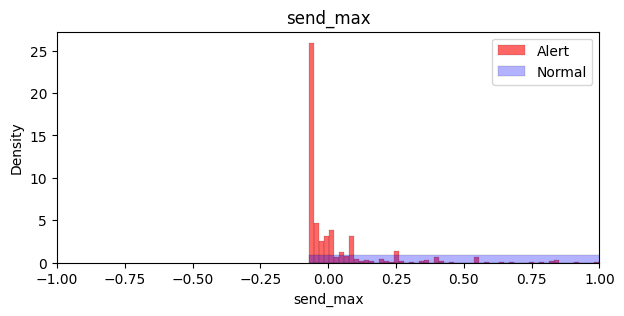

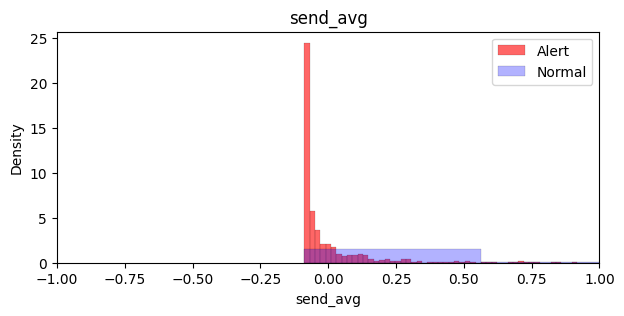

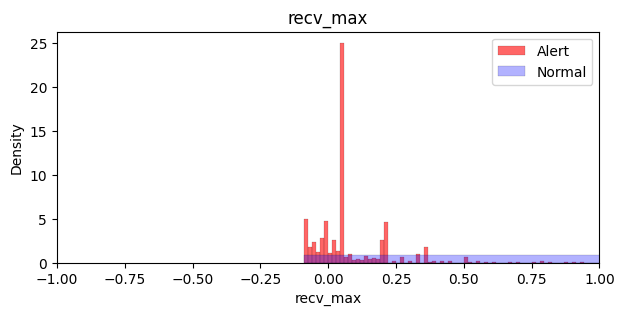

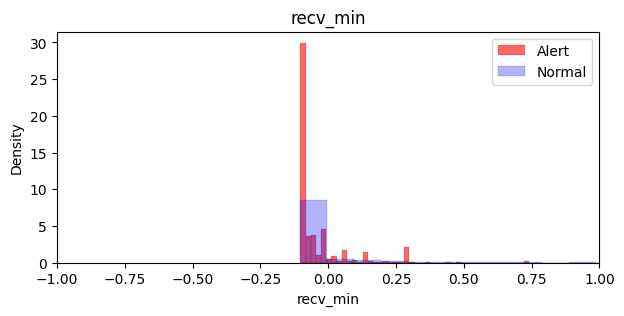

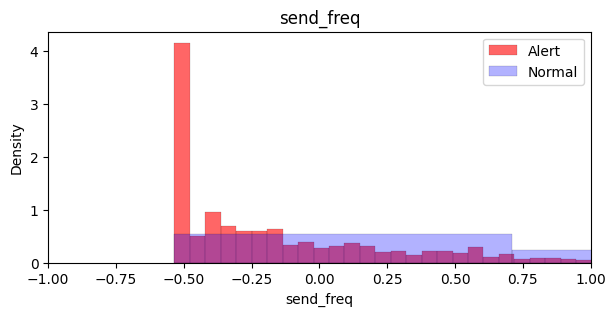

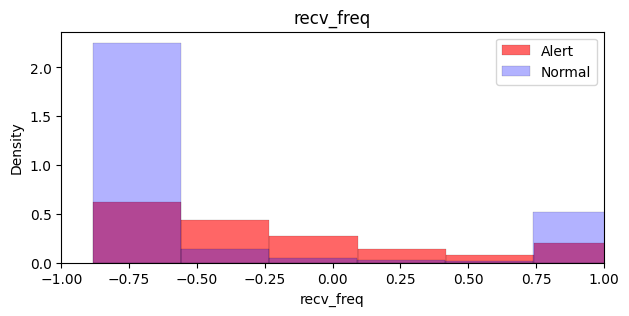

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['send_max', 'send_avg', 'recv_max', 'recv_min', 'send_freq', 'recv_freq']

for col in cols:
    plt.figure(figsize=(7, 3))
    sns.histplot(x_alert[col], color='red', label='Alert', kde=False, stat='density', bins=400, alpha=0.6)
    sns.histplot(x_normal[col], color='blue', label='Normal', kde=False, stat='density', bins=400, alpha=0.3)
    plt.title(col)
    plt.legend()
    plt.xlim(-1, 1)   # 或你想看的 Z-score 區間
    # plt.yscale('log')   # <--- 關鍵行

    plt.show()


適合決策樹、隨機森林等等

模型可嘗試TabNet、TabTransformer(專為表格資料設計)

DecisionTreeClassifier

In [57]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

def Modeling_DTC(datas):
    x_train, y_train = datas[0], datas[1]
    x_valid, y_valid, x_test = datas[2], datas[3], datas[4]
    model = DecisionTreeClassifier(random_state=42)
    model.fit(x_train.drop(columns=['acct']), y_train)
    y_pred = model.predict(x_valid.drop(columns=['acct']))

    acc = accuracy_score(y_valid, y_pred)
    rec = recall_score(y_valid, y_pred)
    prec = precision_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    print("DecisionTreeClassfier")
    print(f"(Finish) Modeling, 驗證集正確率: {acc:.4f}")
    print(f"recall: {rec:.4f}\nprecision: {prec:.4f}\nf1-score: {f1:.4f}\n\n")
    print(classification_report(y_valid, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))

    test_pred = model.predict(x_test.drop(columns=['acct']))
    return test_pred

pred_DTC = Modeling_DTC(datas)

DecisionTreeClassfier
(Finish) Modeling, 驗證集正確率: 0.5669
recall: 0.4554
precision: 1.0000
f1-score: 0.6259


              precision    recall  f1-score   support

           0     0.3210    1.0000    0.4860        26
           1     1.0000    0.4554    0.6259       101

    accuracy                         0.5669       127
   macro avg     0.6605    0.7277    0.5559       127
weighted avg     0.8610    0.5669    0.5972       127

Confusion Matrix:
 [[26  0]
 [55 46]]


LGBMClassifier

In [58]:
from lightgbm import LGBMClassifier

def Modeling_LGB(datas):
    x_train, y_train = datas[0], datas[1]
    x_valid, y_valid, x_test = datas[2], datas[3], datas[4]

    model = LGBMClassifier(
        objective='binary',
        is_unbalance=True,
        random_state=42,
        n_estimators=200
    )

    model.fit(
        x_train.drop(columns=['acct']),
        y_train,
        eval_set=[(x_valid.drop(columns=['acct']), y_valid)],
        # verbose=10  # 不知道是啥 而且編譯不過
        # early_stopping_rounds=20  # 需根據版本及需求加/不加 what is this????????
    )

    y_pred = model.predict(x_valid.drop(columns=['acct']))

    acc = accuracy_score(y_valid, y_pred)
    rec = recall_score(y_valid, y_pred)
    prec = precision_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    print("------------------------------------------------------------------")
    print("LightGBM Classifier")
    print(f"(Finish) Modeling, 驗證集正確率: {acc:.4f}")
    print(f"recall: {rec:.4f}\nprecision: {prec:.4f}\nf1-score: {f1:.4f}\n\n")
    print(classification_report(y_valid, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))

    test_pred = model.predict(x_test.drop(columns=['acct']))
    return test_pred


pred_LGB = Modeling_LGB(datas)

[LightGBM] [Info] Number of positive: 903, number of negative: 327958
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009979 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7741
[LightGBM] [Info] Number of data points in the train set: 328861, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002746 -> initscore=-5.894918
[LightGBM] [Info] Start training from score -5.894918
------------------------------------------------------------------
LightGBM Classifier
(Finish) Modeling, 驗證集正確率: 0.8268
recall: 0.7921
precision: 0.9877
f1-score: 0.8791


              precision    recall  f1-score   support

           0     0.5435    0.9615    0.6944        26
           1     0.9877    0.7921    0.8791       101

    accuracy                         0.8268       127
   macro avg     0.7656    0.8768    0.7868       1

In [46]:
import os
def OutputCSV(path, df_test, x_test, y_pred):
    """
    根據測試資料集及預測結果，產出預測結果之CSV，該CSV可直接上傳於TBrain    
    """
    df_pred = pd.DataFrame({
        'acct': x_test['acct'].values,
        'label': y_pred
    })
    
    df_out = df_test[['acct']].merge(df_pred, on='acct', how='left')
    df_out.to_csv(f"{path}.csv", index=False)    
    
    print(f"(Finish) Output saved to {path}")

In [47]:
OutputCSV('LGB_pred', df_test, x_test, pred_LGB)

(Finish) Output saved to LGB_pred


In [59]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix
import numpy as np

def Modeling_TabNet(datas):
    x_train, y_train = datas[0], datas[1]
    x_valid, y_valid, x_test = datas[2], datas[3], datas[4]

    # 計算類別權重（例如正樣本比負樣本少很多）
    class_weights = {0: 1.0, 1: (len(y_train) - sum(y_train)) / sum(y_train)}
    sample_weight = np.array([class_weights[t] for t in y_train])

    # 只保留數值型欄位（或經過label encoding的所有特徵）
    features = [c for c in x_train.columns if c != 'acct']

    # 建立和訓練TabNet模型
    model = TabNetClassifier(verbose=1)
    model.fit(
        X_train=x_train[features].values,
        y_train=y_train.values,
        weights=sample_weight,
        eval_set=[(x_valid[features].values, y_valid.values)],
        eval_metric=['accuracy'],
        patience=20,
        max_epochs=50,
    )
    y_pred = model.predict(x_valid[features].values)

    acc = accuracy_score(y_valid, y_pred)
    rec = recall_score(y_valid, y_pred)
    prec = precision_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    
    print("TabNet Classifier")
    print(f"(Finish) Modeling, 驗證集正確率: {acc:.4f}")
    print(f"recall: {rec:.4f}\nprecision: {prec:.4f}\nf1-score: {f1:.4f}\n\n")
    print(classification_report(y_valid, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))
    
    test_pred = model.predict(x_test[features].values)
    return test_pred

pred_TabNet = Modeling_TabNet(datas)


/mnt/c/ncku/AI/final project/venv/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.32729 | val_0_accuracy: 0.89764 |  0:00:12s
epoch 1  | loss: 0.25011 | val_0_accuracy: 0.87402 |  0:00:27s
epoch 2  | loss: 0.22511 | val_0_accuracy: 0.89764 |  0:00:40s
epoch 3  | loss: 0.20785 | val_0_accuracy: 0.91339 |  0:00:55s
epoch 4  | loss: 0.19933 | val_0_accuracy: 0.90551 |  0:01:08s
epoch 5  | loss: 0.194   | val_0_accuracy: 0.89764 |  0:01:20s
epoch 6  | loss: 0.18208 | val_0_accuracy: 0.89764 |  0:01:37s
epoch 7  | loss: 0.18033 | val_0_accuracy: 0.91339 |  0:01:49s
epoch 8  | loss: 0.18587 | val_0_accuracy: 0.89764 |  0:02:01s
epoch 9  | loss: 0.17367 | val_0_accuracy: 0.88189 |  0:02:16s
epoch 10 | loss: 0.17254 | val_0_accuracy: 0.91339 |  0:02:29s
epoch 11 | loss: 0.17302 | val_0_accuracy: 0.91339 |  0:02:44s
epoch 12 | loss: 0.16702 | val_0_accuracy: 0.90551 |  0:02:56s
epoch 13 | loss: 0.16526 | val_0_accuracy: 0.90551 |  0:03:09s
epoch 14 | loss: 0.15833 | val_0_accuracy: 0.90551 |  0:03:24s
epoch 15 | loss: 0.15734 | val_0_accuracy: 0.91339 |  0

/mnt/c/ncku/AI/final project/venv/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Classifier
(Finish) Modeling, 驗證集正確率: 0.9134
recall: 0.9604
precision: 0.9327
f1-score: 0.9463


              precision    recall  f1-score   support

           0     0.8261    0.7308    0.7755        26
           1     0.9327    0.9604    0.9463       101

    accuracy                         0.9134       127
   macro avg     0.8794    0.8456    0.8609       127
weighted avg     0.9109    0.9134    0.9114       127

Confusion Matrix:
 [[19  7]
 [ 4 97]]


In [165]:
OutputCSV('TabNet_pred', df_test, x_test, pred_TabNet)

(Finish) Output saved to TabNet_pred
